# G-Memory
 Demo

This notebook is tuned for a short live walkthrough. Each code cell answers one question:

1. Did memory help?
2. How did the action pattern change?
3. What memory was actually retrieved?
4. What should you say when you show the result?

## 1. Load The Stable Compare Record

This notebook uses the published compare JSON first, then falls back to the latest cached run. That makes it safe for a live audience walkthrough.

In [1]:
from pathlib import Path
import json
import re
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "demo" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from demo.utils.caching import latest_json

NOT_EXPOSED = "not exposed by current code path"


def resolve_compare_json():
    published = PROJECT_ROOT / "demo/published/latest_compare.json"
    if published.exists():
        return published
    cached = latest_json(PROJECT_ROOT / "demo/cached_runs")
    if cached is not None and cached.exists():
        return cached
    raise FileNotFoundError("No published or cached compare JSON is available.")


def parse_numbered_lines(text):
    matches = re.findall(r"\d+\.\s+(.*?)(?=\n\d+\.|\Z)", text.strip(), flags=re.DOTALL)
    return [match.strip() for match in matches] or [text.strip()]


def meaningful_items(items):
    return [item for item in items if item not in ("", None, NOT_EXPOSED)]


def action_list(view):
    return [step.get("action", "") for step in view.get("steps", [])]


def count_prefix(actions, prefix):
    return sum(action.startswith(prefix) for action in actions)


def pickup_batches_before_move(actions):
    batches = []
    current_batch = 0
    for action in actions:
        if action.startswith("pick "):
            current_batch += 1
        elif action.startswith("move "):
            if current_batch:
                batches.append(current_batch)
                current_batch = 0
    return batches


compare_json = resolve_compare_json()
compare_record = json.loads(compare_json.read_text(encoding="utf-8"))
compare_payload = compare_record["compare_payload"]
baseline_view = compare_payload["no_memory"]
gmemory_view = compare_payload["gmemory"]

print(f"Loaded compare record: {compare_json}")
print(f"Run id: {compare_record['run_id']}")
print(f"Backend: {compare_record['backend']}")
print(f"Delta summary: {compare_payload['delta_summary']}")

Loaded compare record: /Users/sergey/code/comp7404-gmemory-poster-demo/demo/published/latest_compare.json
Run id: pddl-autogen-mock-20260419T043651Z
Backend: mock
Delta summary: G-Memory succeeds where the empty-memory baseline fails. It retrieves 1 related historical query nodes and 2 insight nodes, then injects role-specific memory packets before action selection.


## 2. Executive Summary

This table is the fastest way to explain the advantage. The most important columns are `Done`, `Room changes`, and `Pickup batches before move`.

In [2]:
summary_rows = []
for label, view in [("No Memory", baseline_view), ("G-Memory", gmemory_view)]:
    actions = action_list(view)
    batches = pickup_batches_before_move(actions)
    summary_rows.append(
        {
            "Mode": label,
            "Reward": view.get("final_reward"),
            "Done": view.get("final_done"),
            "Steps used": len(actions),
            "Room changes": count_prefix(actions, "move "),
            "Balls dropped": count_prefix(actions, "drop "),
            "Pickup batches before move": ", ".join(str(batch) for batch in batches) or "-",
            "Retrieved insights": len(meaningful_items(view.get("selected_insights", []))),
            "Transport pattern": "single-ball trips" if max(batches or [0]) <= 1 else "two-ball batches",
        }
    )
pd.DataFrame(summary_rows)

Mode,Reward,Done,Steps used,Room changes,Balls dropped,Pickup batches before move,Retrieved insights,Transport pattern
No Memory,0.75,False,11,5,3,"1, 1, 1",0,single-ball trips
G-Memory,1.00,True,11,3,4,"2, 2",2,two-ball batches


## 3. Action Pattern Difference

The baseline keeps doing one-ball trips. The G-Memory run switches to two-ball batches before each room change.

In [3]:
baseline_actions = action_list(baseline_view)
gmemory_actions = action_list(gmemory_view)
max_len = max(len(baseline_actions), len(gmemory_actions))
pd.DataFrame(
    {
        "Step": list(range(1, max_len + 1)),
        "No memory action": baseline_actions + [""] * (max_len - len(baseline_actions)),
        "G-Memory action": gmemory_actions + [""] * (max_len - len(gmemory_actions)),
    }
)

Step,No memory action,G-Memory action
1,pick ball1 rooma right,pick ball1 rooma right
2,move rooma roomb,pick ball2 rooma left
3,drop ball1 roomb right,move rooma roomb
4,move roomb rooma,drop ball1 roomb right
5,pick ball2 rooma right,drop ball2 roomb left
6,move rooma roomb,move roomb rooma
7,drop ball2 roomb right,pick ball3 rooma right
8,move roomb rooma,pick ball4 rooma left
9,pick ball3 rooma right,move rooma roomb
10,move rooma roomb,drop ball3 roomb right


## 4. Retrieved Memory Evidence

These cells show the exact evidence that the G-Memory run exposes back to the agents.

In [4]:
pd.DataFrame({"Retrieved task candidate": gmemory_view["retrieved_historical_queries"]})

Retrieved task candidate
"The goal is to satisfy the following conditions: ball1 is at roomb. , ball2 is at roomb. , ball3 is at roomb. , ball4 is at roomb."


In [5]:
pd.DataFrame(
    {
        "Selected successful key step": parse_numbered_lines(
            gmemory_view["selected_successful_trajectories"][0]["key_steps"]
        )
    }
)

Selected successful key step
Identify which balls still need to reach the target room.
Pick up one or two balls in rooma using the available grippers.
Move from rooma to roomb only after the intended pickup batch is ready.
Drop the carried balls in roomb and repeat until all goal conditions are satisfied.


In [6]:
pd.DataFrame({"Selected insight": meaningful_items(gmemory_view["selected_insights"])})

Selected insight
"Carry two transferable objects before moving between rooms, because batching transfers reduces wasted travel."
"Reuse both grippers when possible, because parallel pickups shorten the full interaction trajectory."


## 5. Role-Specific Memory Packets

The same retrieved case is then repackaged for each agent role. That is the bridge from retrieval to changed behavior.

In [7]:
packet_rows = []
for agent_name, packet in gmemory_view["agent_memory_packets"].items():
    packet_rows.append(
        {
            "Agent": agent_name,
            "Role": packet.get("role"),
            "Reference cases": len(packet.get("successful_reference_cases", [])),
            "Memory packet": " | ".join(packet.get("insights", [])) or "No role-specific packet",
        }
    )
pd.DataFrame(packet_rows)

Agent,Role,Reference cases,Memory packet
solver,solver,1,"Carry two balls before moving rooms, because batching transfers keeps the solver inside the step budget. | Treat both grippers as active resources, because unused capacity slows the plan unnecessarily."
ground_truth,ground truth agent,1,"Recommend the two-gripper transfer pattern first, because your role is to break the solver out of inefficient loops. | Call out unnecessary room changes, because corrective guidance should focus on the main budget bottleneck."


## 6. Visuals

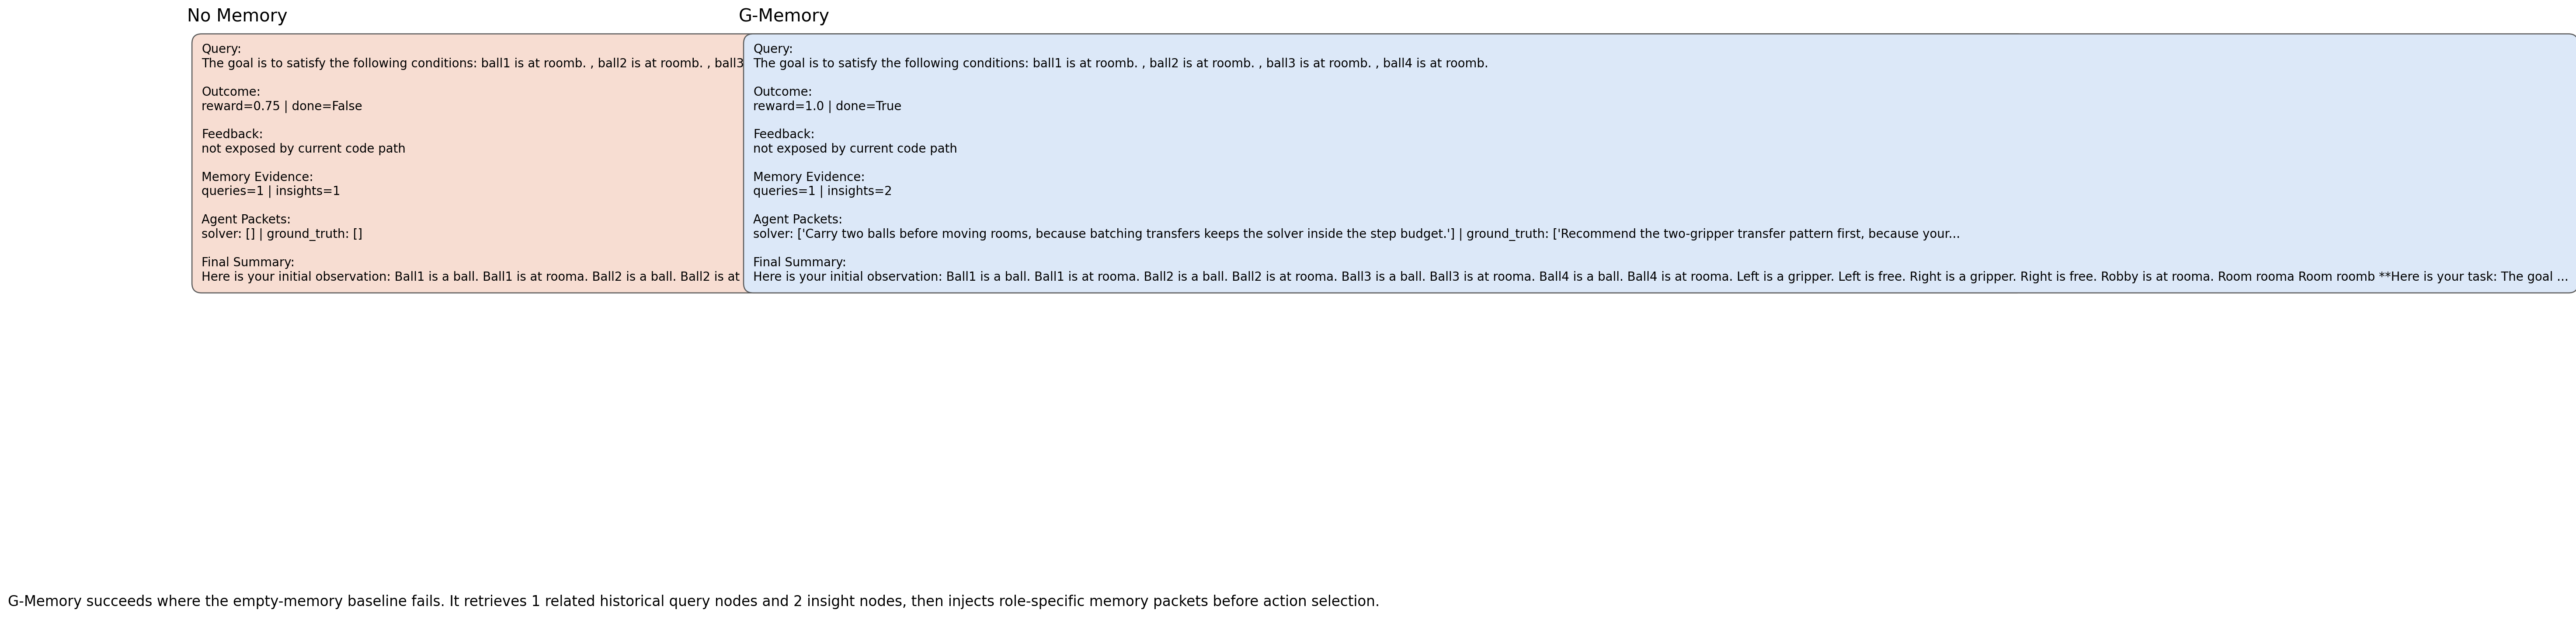

In [8]:
display(Image(filename=str(PROJECT_ROOT / "demo/published/latest_compare.png"), width=900))

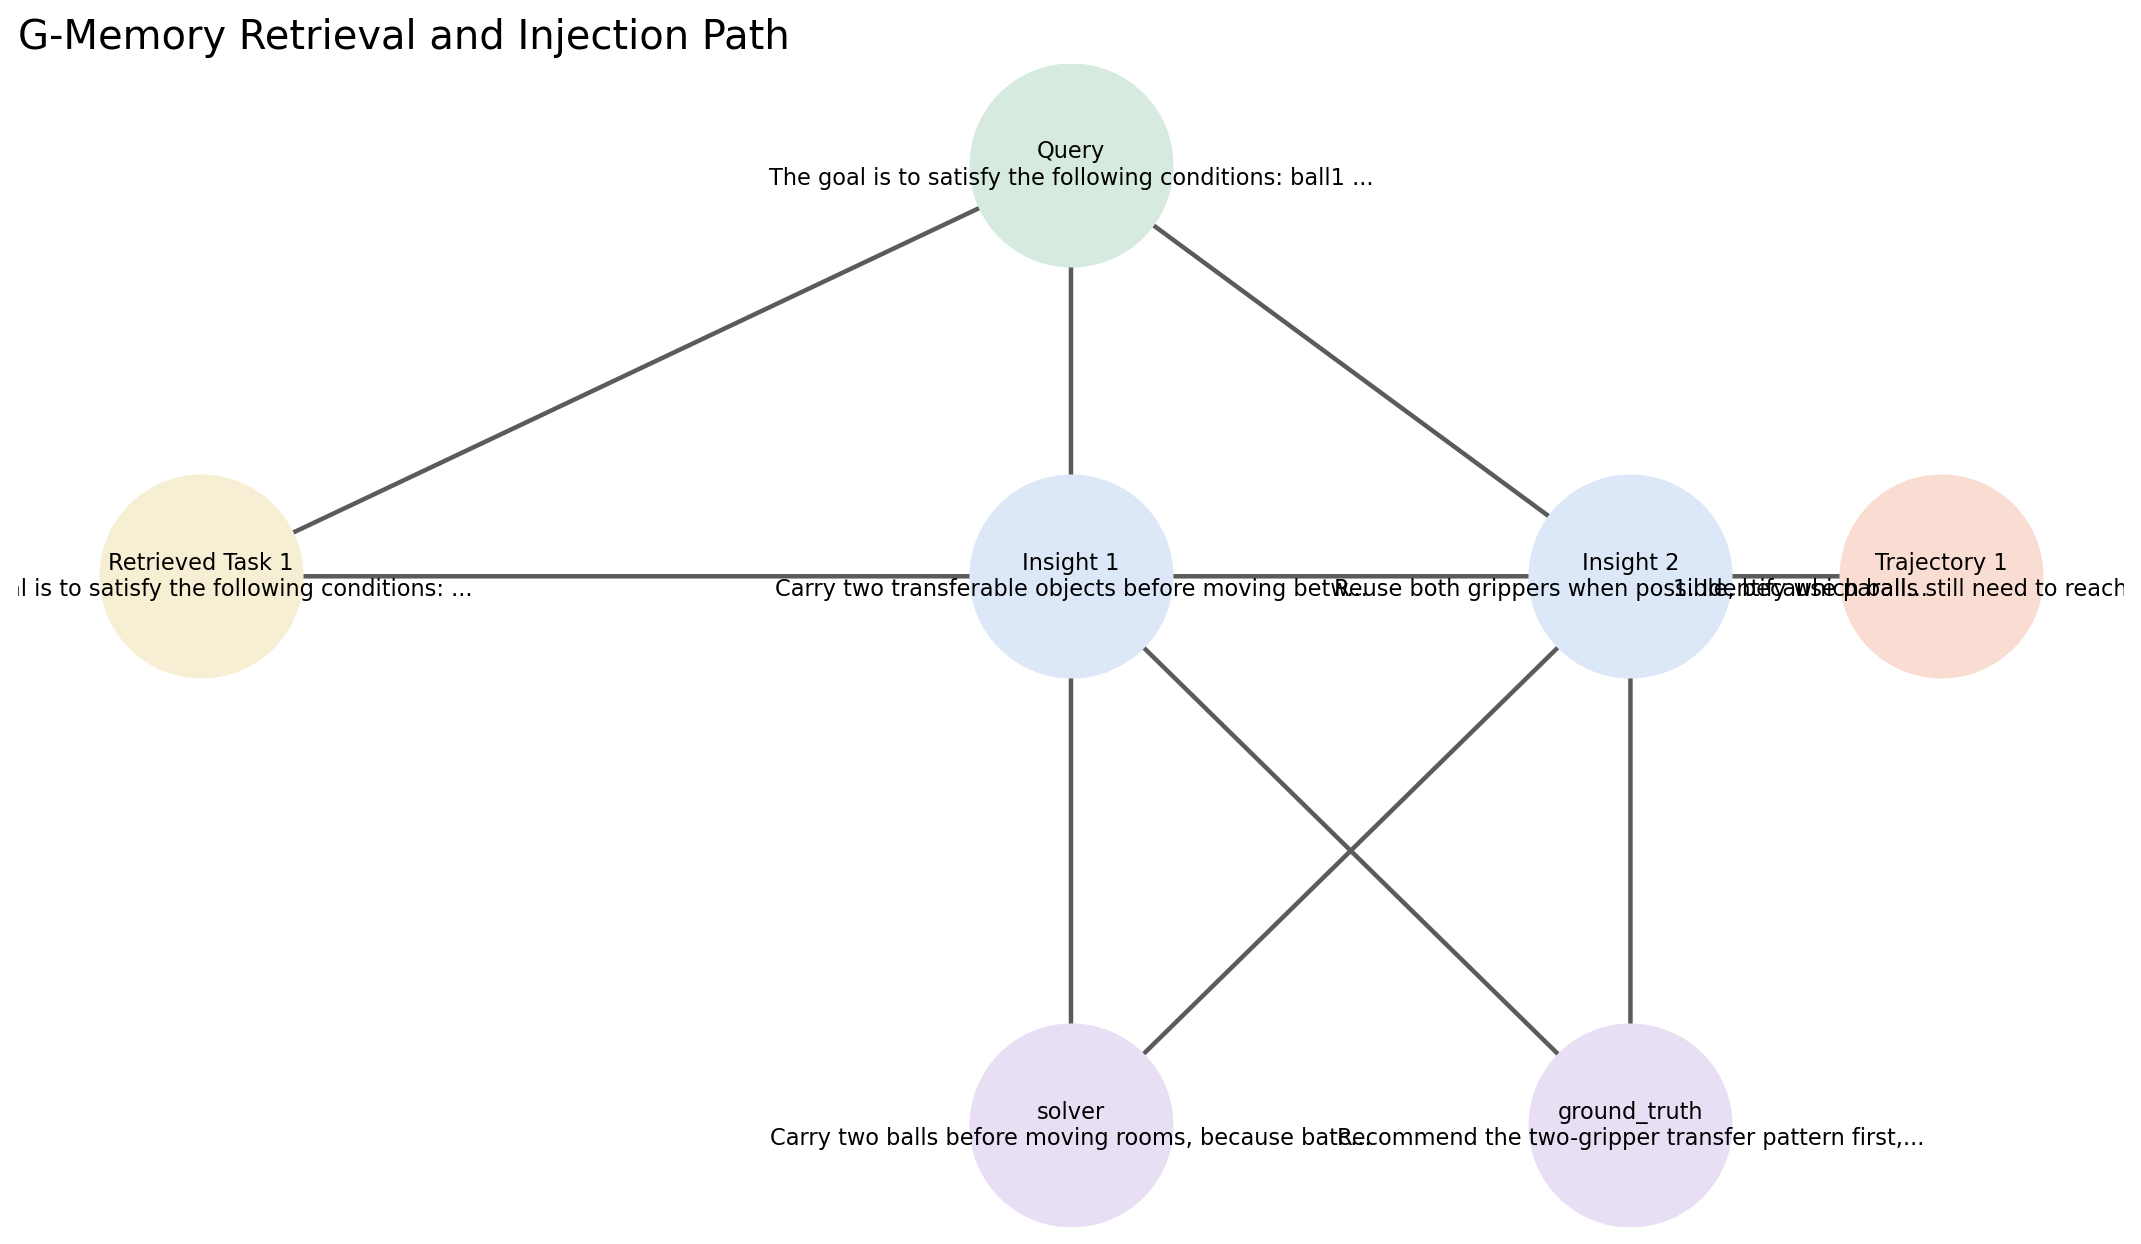

In [9]:
display(Image(filename=str(PROJECT_ROOT / "demo/published/latest_memory_flow.png"), width=900))